# DogFaceNet_large Dataset Summary

이 노트북은 `DogFaceNet_large` 폴더를 기준으로 다음 정보를 분석합니다.

- ID(폴더) 개수
- 빈 폴더 존재 여부
- 총 이미지 샘플 수
- 폴더 내 이미지 개수 분포
- 상/하위 이미지 개수 폴더 목록


In [19]:
from pathlib import Path
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Dataset root (필요 시 수정)
DATASET_ROOT = Path('/data/dogfacenet/dataset/DogFaceNet_large/images_2')

# 이미지 확장자 (필요 시 추가)
IMAGE_EXTS = {'.jpg', '.jpeg', '.png', '.bmp', '.tif', '.tiff', '.webp'}

def is_image_file(p: Path) -> bool:
    return p.is_file() and p.suffix.lower() in IMAGE_EXTS

def safe_name(p: Path) -> str:
    # 깨진 폴더명 대응용 (surrogateescape가 있을 수 있어 bytes->str 안전 변환)
    try:
        return p.name
    except Exception:
        return os.fsdecode(p.name)


In [20]:
# 폴더 목록 수집
id_dirs = [p for p in DATASET_ROOT.iterdir() if p.is_dir()]

# 각 ID별 이미지 개수 계산
records = []
for d in id_dirs:
    img_count = sum(1 for f in d.iterdir() if is_image_file(f))
    records.append({
        'id_folder': safe_name(d),
        'path': str(d),
        'image_count': img_count,
    })

df = pd.DataFrame(records).sort_values('image_count', ascending=False)

empty_dirs = df[df['image_count'] == 0]
non_empty_dirs = df[df['image_count'] > 0]

print(f'Total ID folders (all): {len(id_dirs)}')
print(f'Total ID folders (non-empty): {len(non_empty_dirs)}')
print(f'Empty folders: {len(empty_dirs)}')

df.head()


Total ID folders (all): 2522
Total ID folders (non-empty): 2503
Empty folders: 19


,id_folder,path,image_count
1047,Wanda,/data/dogfacenet/dataset/DogFaceNet_large/imag...,38
993,Morris-2,/data/dogfacenet/dataset/DogFaceNet_large/imag...,29
2181,Nozis,/data/dogfacenet/dataset/DogFaceNet_large/imag...,28
1254,Csocsi,/data/dogfacenet/dataset/DogFaceNet_large/imag...,27
1439,Snoopy-3,/data/dogfacenet/dataset/DogFaceNet_large/imag...,27


In [21]:
df[df['id_folder']=='Wanda'].path.values[0]

'/data/dogfacenet/dataset/DogFaceNet_large/images_2/Wanda'

In [22]:
total_images = int(df['image_count'].sum())
empty_dirs = df[df['image_count'] == 0]

print(f'Total images: {total_images}')
print(f'Empty folders: {len(empty_dirs)}')
if len(empty_dirs) > 0:
    display(empty_dirs.head(20))


Total images: 11162
Empty folders: 19


,id_folder,path,image_count
2367,70971-wir-suchen-eine-kleine-weiblic,/data/dogfacenet/dataset/DogFaceNet_large/imag...,0
2154,70754-rottweiler-ruede,/data/dogfacenet/dataset/DogFaceNet_large/imag...,0
2436,70784-gesucht-zweithund,/data/dogfacenet/dataset/DogFaceNet_large/imag...,0
1949,Jajo,/data/dogfacenet/dataset/DogFaceNet_large/imag...,0
2108,401723,/data/dogfacenet/dataset/DogFaceNet_large/imag...,0
66,Fan_Fan,/data/dogfacenet/dataset/DogFaceNet_large/imag...,0
2155,Jara-4,/data/dogfacenet/dataset/DogFaceNet_large/imag...,0
920,401725,/data/dogfacenet/dataset/DogFaceNet_large/imag...,0
84,70925-suche-familienhumd,/data/dogfacenet/dataset/DogFaceNet_large/imag...,0
1123,Limoncello,/data/dogfacenet/dataset/DogFaceNet_large/imag...,0


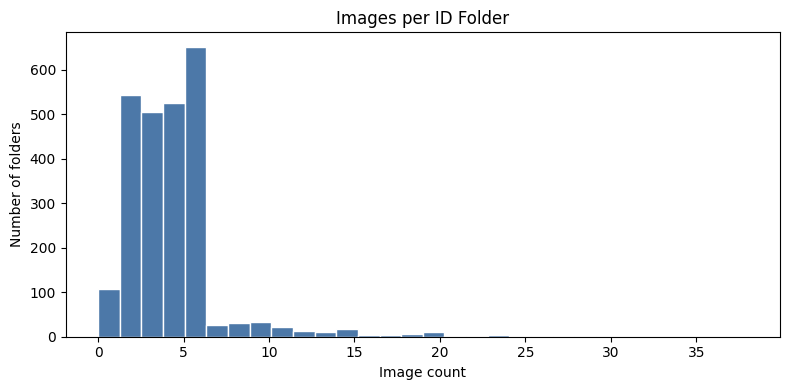

In [23]:
# 이미지 개수 분포
plt.figure(figsize=(8, 4))
plt.hist(df['image_count'], bins=30, color='#4C78A8', edgecolor='white')
plt.title('Images per ID Folder')
plt.xlabel('Image count')
plt.ylabel('Number of folders')
plt.tight_layout()
plt.show()


In [24]:
# 상위/하위 폴더
print('Top 10 folders by image count')
display(df.head(10))

print('Bottom 10 folders by image count')
display(df.tail(10))


Top 10 folders by image count


,id_folder,path,image_count
1047,Wanda,/data/dogfacenet/dataset/DogFaceNet_large/imag...,38
993,Morris-2,/data/dogfacenet/dataset/DogFaceNet_large/imag...,29
2181,Nozis,/data/dogfacenet/dataset/DogFaceNet_large/imag...,28
1254,Csocsi,/data/dogfacenet/dataset/DogFaceNet_large/imag...,27
1439,Snoopy-3,/data/dogfacenet/dataset/DogFaceNet_large/imag...,27
1848,Kismacko,/data/dogfacenet/dataset/DogFaceNet_large/imag...,26
1359,Szandra,/data/dogfacenet/dataset/DogFaceNet_large/imag...,26
16,Clara-4,/data/dogfacenet/dataset/DogFaceNet_large/imag...,24
319,Oasis,/data/dogfacenet/dataset/DogFaceNet_large/imag...,24
620,Andor-4,/data/dogfacenet/dataset/DogFaceNet_large/imag...,23


Bottom 10 folders by image count


,id_folder,path,image_count
1123,Limoncello,/data/dogfacenet/dataset/DogFaceNet_large/imag...,0
885,Scooby_Doo,/data/dogfacenet/dataset/DogFaceNet_large/imag...,0
57,401705,/data/dogfacenet/dataset/DogFaceNet_large/imag...,0
1150,Zeno-3,/data/dogfacenet/dataset/DogFaceNet_large/imag...,0
1596,L걎y_,/data/dogfacenet/dataset/DogFaceNet_large/imag...,0
2388,Django-2,/data/dogfacenet/dataset/DogFaceNet_large/imag...,0
583,Lady_Gaga,/data/dogfacenet/dataset/DogFaceNet_large/imag...,0
567,paula-275,/data/dogfacenet/dataset/DogFaceNet_large/imag...,0
1197,Jari,/data/dogfacenet/dataset/DogFaceNet_large/imag...,0
934,70742-gesucht-labrador-oder-golden-r,/data/dogfacenet/dataset/DogFaceNet_large/imag...,0


In [25]:
# 요약 통계
summary = df['image_count'].describe()
summary


count    2522.000000
mean        4.425852
std         3.097557
min         0.000000
25%         2.000000
50%         4.000000
75%         6.000000
max        38.000000
Name: image_count, dtype: float64